# Computational validation of stimulus specificity

This notebook provides computational validation of the specificity gradient in our
adjective–noun triad stimuli using two complementary approaches:

1. **Sentence-BERT embeddings**: We quantify whether the mid-specificity phrase
   (*nocturnal bird*) moves the semantic representation closer to the high-specificity
   target (*owl*) relative to the low-specificity baseline (*bird*).
2. **WordNet taxonomic depth**: We verify that high-specificity nouns sit deeper in
   the WordNet hypernym hierarchy than their low-specificity counterparts, and confirm
   the hyponymy relationship for each low–high pair.

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics.pairwise import cosine_similarity
from sentence_transformers import SentenceTransformer
import nltk
from nltk.corpus import wordnet as wn

# Ensure WordNet data is downloaded
try:
    nltk.data.find('corpora/wordnet.zip')
except LookupError:
    print("Downloading WordNet data...")
    nltk.download('wordnet')
    nltk.download('omw-1.4')

import fig_constants  # just importing this applies all the rcParams globally
import fig_helpers as fh

/Users/ryanlaw/miniconda3/envs/transformer/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Load and Prepare Data

We load the stimulus CSV and construct the full strings for analysis. 
* **Low**: `word2` (e.g., "bird")
* **Mid**: `word1` + `word2` (e.g., "nocturnal bird")
* **High**: `word2` (e.g., "owl")

In [2]:
df = pd.read_excel('stimuli_specificity_complete.xlsx')
df['stimulus'] = np.where(
    df['specificity'] == 'mid',
    df['word1'].astype(str) + ' ' + df['word2'].astype(str),
    df['word2'].astype(str)
)
df['stimulus_type'] = np.where(df['specificity'] == 'mid', 'phrase', 'word')
print(f'Loaded {len(df)} stimuli across {df.set_nr.nunique()} sets.')

Loaded 300 stimuli across 100 sets.


## 2. Vector Space Analysis (S-BERT)

We use the `all-MiniLM-L6-v2` model to generate embeddings. We then calculate the **Specificity Gain**: how much closer the 'Mid' phrase moves the semantic representation towards the 'High' target, relative to the 'Low' baseline.

In [3]:
def analyze_embeddings(df, model_name='all-MiniLM-L6-v2'):
    if df is None: return None
    
    print(f"Loading SentenceTransformer model: {model_name}...")
    model = SentenceTransformer(model_name)
    
    # Pivot to wide format for set-wise comparison
    pivot_df = df.pivot_table(index='set_nr', columns='specificity', values='stimulus', aggfunc='first').reset_index()
    
    # 1. Generate Embeddings efficiently (unique items only)
    unique_stimuli = pd.concat([pivot_df['low'], pivot_df['mid'], pivot_df['high']]).dropna().unique()
    print(f"Encoding {len(unique_stimuli)} unique stimuli...")
    embeddings = model.encode(unique_stimuli)
    emb_dict = {stim: emb for stim, emb in zip(unique_stimuli, embeddings)}
    
    # 2. Define similarity helper
    def get_sim(s1, s2):
        if s1 not in emb_dict or s2 not in emb_dict: return np.nan
        return cosine_similarity(emb_dict[s1].reshape(1, -1), emb_dict[s2].reshape(1, -1))[0][0]

    # 3. Calculate metrics
    print("Calculating semantic similarities...")
    pivot_df['sim_low_high'] = pivot_df.apply(lambda x: get_sim(x['low'], x['high']), axis=1)
    pivot_df['sim_mid_high'] = pivot_df.apply(lambda x: get_sim(x['mid'], x['high']), axis=1)
    pivot_df['sim_low_mid']  = pivot_df.apply(lambda x: get_sim(x['low'], x['mid']), axis=1)
    
    # Specificity Gain: (Sim(Mid, High) - Sim(Low, High))
    pivot_df['specificity_gain'] = pivot_df['sim_mid_high'] - pivot_df['sim_low_high']
    
    return pivot_df

# Run analysis
emb_results = analyze_embeddings(df)

Loading SentenceTransformer model: all-MiniLM-L6-v2...
Encoding 259 unique stimuli...
Calculating semantic similarities...


## 3. Taxonomic depth analysis (WordNet)

We verify the hyponymy relationship for each low–high noun pair and confirm that
high-specificity nouns sit deeper in the WordNet hypernym hierarchy.

An initial analysis using only the first (most frequent) synset per word failed to
recover many valid pairs — e.g., *crane* defaulted to the machine sense rather than
the bird. We therefore use a robust search across all noun synsets, returning the
best-matching relationship found. The depth statistics use the first synset as a
consistent reference point.

In [4]:
def get_relationship_robust(low_word, high_word):
    """Check all noun synset combinations for a hypernym/hyponym relationship.

    Parameters
    ----------
    low_word, high_word : str
        The general and specific noun of a triad pair.

    Returns
    -------
    relationship : str
        One of 'direct_hyponym', 'indirect_hyponym', 'no_wordnet_relation', 'not_found'.
    low_syn_name, high_syn_name : str or None
        Names of the matched synsets (from first synset if no match found).
    """
    low_synsets  = wn.synsets(low_word,  pos=wn.NOUN)
    high_synsets = wn.synsets(high_word, pos=wn.NOUN)

    if not low_synsets or not high_synsets:
        return 'not_found', None, None

    for low_syn in low_synsets:
        direct_hyponyms = low_syn.hyponyms()
        all_hyponyms    = list(low_syn.closure(lambda s: s.hyponyms()))
        for high_syn in high_synsets:
            if high_syn in direct_hyponyms:
                return 'direct_hyponym',   low_syn.name(), high_syn.name()
            if high_syn in all_hyponyms:
                return 'indirect_hyponym', low_syn.name(), high_syn.name()

    return 'no_wordnet_relation', low_synsets[0].name(), high_synsets[0].name()


def get_depth(word):
    """Return the WordNet max depth and synset name for a word (first noun synset)."""
    synsets = wn.synsets(word, pos=wn.NOUN)
    if not synsets:
        return np.nan, None
    syn = synsets[0]
    return syn.max_depth(), syn.name()


def classify_level_contrast(low_depth, high_depth):
    """Classify a low–high pair by the taxonomic levels it spans.

    Thresholds follow approximate WordNet conventions:
    superordinate ~depth 4–6, basic ~7–9, subordinate ~10+.
    """
    if pd.isna(low_depth) or pd.isna(high_depth):
        return 'unknown'
    if low_depth <= 6 and 7 <= high_depth <= 9:
        return 'superordinate → basic'
    elif 7 <= low_depth <= 9 and high_depth >= 10:
        return 'basic → subordinate'
    elif low_depth <= 6 and high_depth >= 10:
        return 'superordinate → subordinate'
    else:
        return 'other'


# Build pivot of low/high word pairs
pivot = (df[df['specificity'].isin(['low', 'high'])]
         .pivot_table(index='set_nr', columns='specificity', values='word2', aggfunc='first')
         .reset_index())

rows = []
for _, row in pivot.iterrows():
    relationship, low_syn, high_syn = get_relationship_robust(row['low'], row['high'])
    low_depth,  low_syn_name  = get_depth(row['low'])
    high_depth, high_syn_name = get_depth(row['high'])
    rows.append({
        'set_nr'      : row['set_nr'],
        'low_word'    : row['low'],
        'high_word'   : row['high'],
        'low_synset'  : low_syn_name,
        'high_synset' : high_syn_name,
        'low_depth'   : low_depth,
        'high_depth'  : high_depth,
        'depth_diff'  : (high_depth - low_depth) if pd.notna(low_depth) and pd.notna(high_depth) else np.nan,
        'relationship': relationship,
    })

results_df = pd.DataFrame(rows)
results_df['level_contrast'] = results_df.apply(
    lambda r: classify_level_contrast(r['low_depth'], r['high_depth']), axis=1)

# Summary
print('Relationship types:')
print(results_df['relationship'].value_counts())
print(f'\nLevel contrasts:')
print(results_df['level_contrast'].value_counts())
print(f'\nPairs with no WordNet relation ({results_df["relationship"].eq("no_wordnet_relation").sum()}):')
print(results_df[results_df['relationship'] == 'no_wordnet_relation']
      [['low_word', 'high_word', 'low_synset', 'high_synset']].to_string(index=False))

Relationship types:
relationship
indirect_hyponym       55
direct_hyponym         23
no_wordnet_relation    18
not_found               4
Name: count, dtype: int64

Level contrasts:
level_contrast
other                          43
basic → subordinate            30
superordinate → basic          19
unknown                         4
superordinate → subordinate     4
Name: count, dtype: int64

Pairs with no WordNet relation (18):
 low_word high_word     low_synset   high_synset
 building   factory  building.n.01  factory.n.01
    cream  ointment     cream.n.01 ointment.n.01
      dog  Labrador       dog.n.01 labrador.n.01
   flower  daffodil    flower.n.01 daffodil.n.01
   flower      rose    flower.n.01     rose.n.01
      hat    helmet       hat.n.01   helmet.n.01
    horse     zebra     horse.n.01    zebra.n.01
   planet    Saturn    planet.n.01   saturn.n.01
 predator     shark  marauder.n.01    shark.n.01
     rank   admiral      rank.n.01  admiral.n.01
    river    stream     river.n

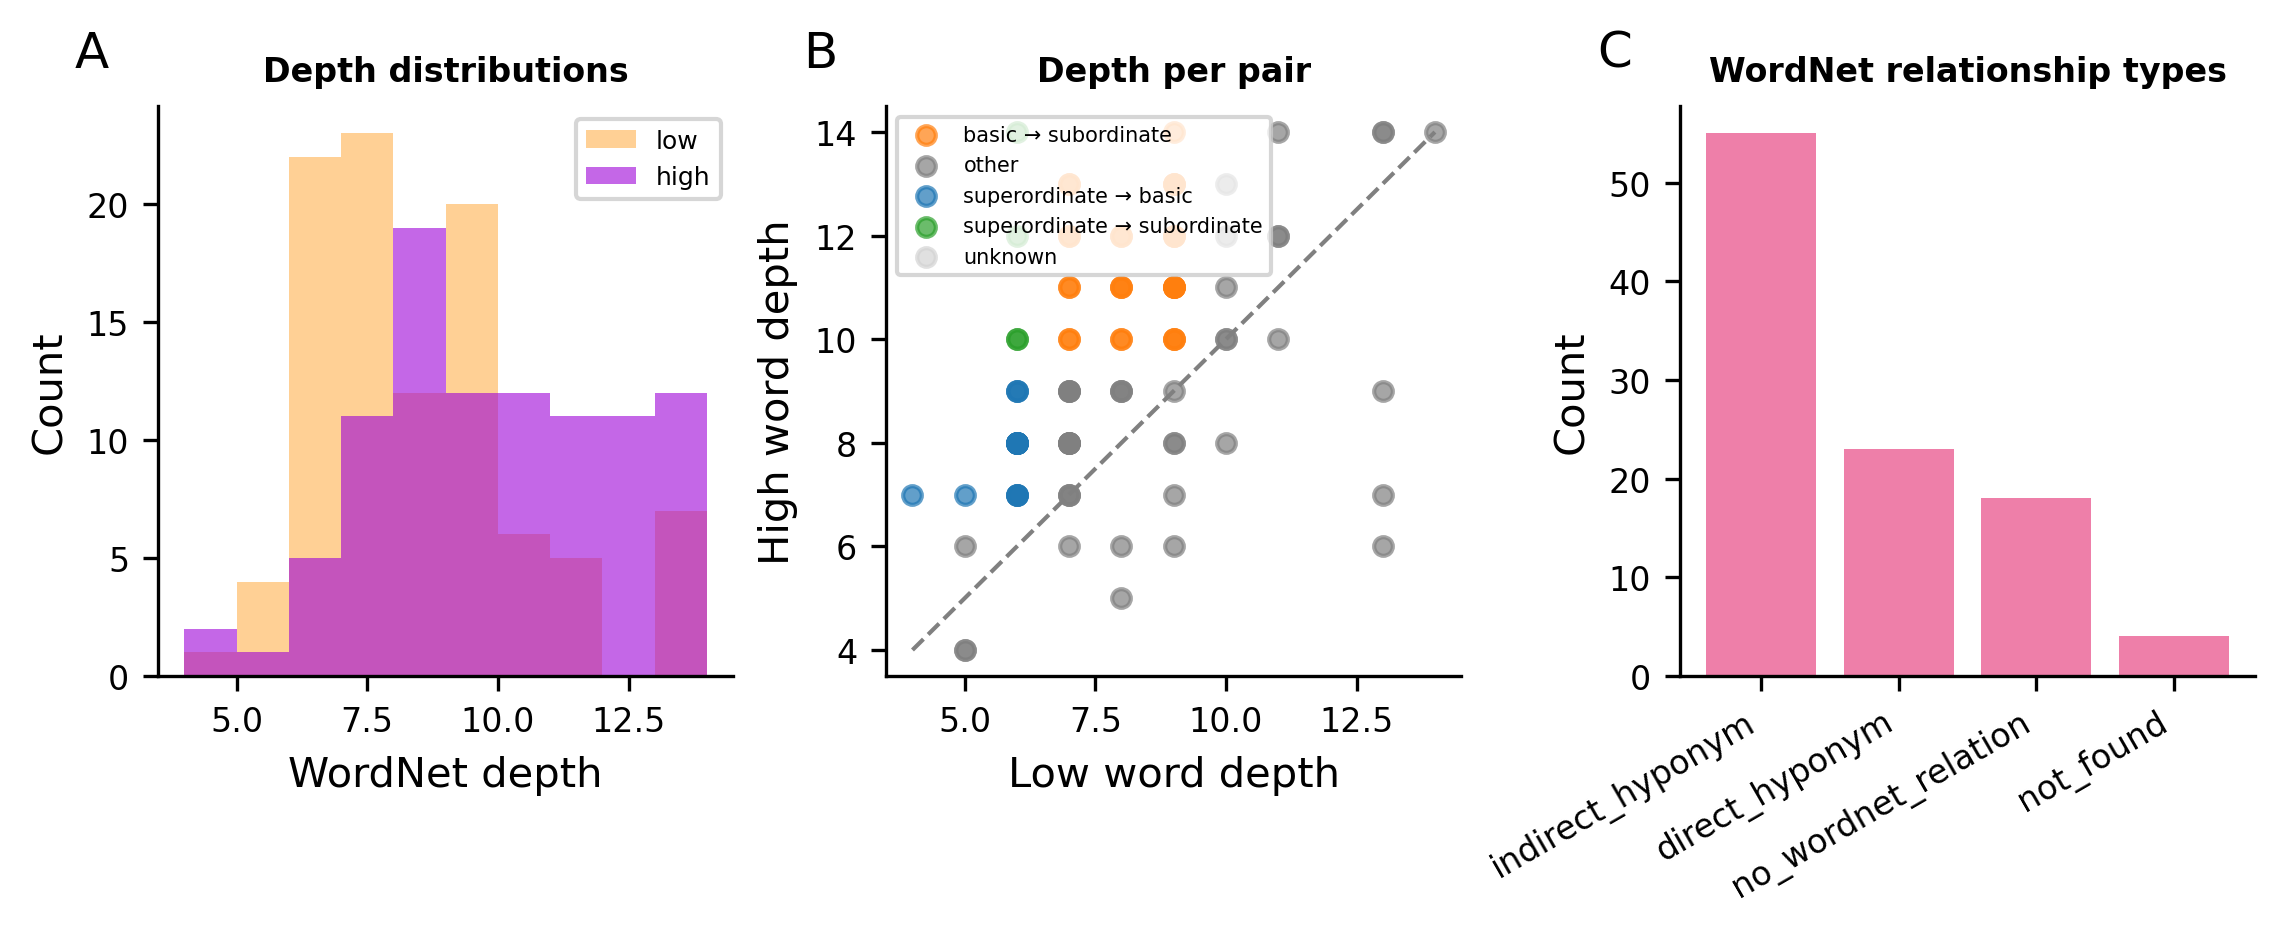

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(fig_constants.FIG_WIDTH, 3.),
                          dpi=300, constrained_layout=True)

# Panel A: WordNet depth distributions, low vs high
axes[0].hist(results_df['low_depth'].dropna(),  bins=10, alpha=0.6,
             label='low',  color='#ffb14e')
axes[0].hist(results_df['high_depth'].dropna(), bins=10, alpha=0.6,
             label='high', color='#9d02d7')
axes[0].set(xlabel='WordNet depth', ylabel='Count', title='Depth distributions')
axes[0].legend()

# Panel B: scatter of low vs high depth per pair, coloured by level contrast
COLOR_MAP = {
    'superordinate → basic'      : '#1f77b4',
    'basic → subordinate'        : '#ff7f0e',
    'superordinate → subordinate': '#2ca02c',
    'other'                      : 'grey',
    'unknown'                    : 'lightgrey',
}
for contrast_type, group in results_df.groupby('level_contrast'):
    axes[1].scatter(group['low_depth'], group['high_depth'],
                    label=contrast_type, color=COLOR_MAP.get(contrast_type, 'grey'),
                    alpha=0.7, s=20)
axes[1].plot([4, 14], [4, 14], '--', color='grey', linewidth=1)  # identity line
axes[1].set(xlabel='Low word depth', ylabel='High word depth', title='Depth per pair')
axes[1].legend(fontsize=5, loc='upper left')

# Panel C: WordNet relationship types
rel_counts = results_df['relationship'].value_counts()
axes[2].bar(range(len(rel_counts)), rel_counts.values, color='#ea5f94', alpha=0.8)
axes[2].set_xticks(range(len(rel_counts)))
axes[2].set_xticklabels(rel_counts.index, rotation=30, ha='right')
axes[2].set(ylabel='Count', title='WordNet relationship types')

fh.label_panels_mosaic(fig, {'A': axes[0], 'B': axes[1], 'C': axes[2]})
plt.savefig('fig_wordnet_pair_analysis.pdf', bbox_inches='tight')
plt.show()

## 5. Summary statistics and statistical tests

In [6]:
from scipy.stats import ttest_1samp, ttest_rel

# --- S-BERT: one-sample t-test of specificity gain vs 0 ---
# H0: the phrase is no closer to the specific target than the base word is
t, p = ttest_1samp(emb_results['specificity_gain'], popmean=0)
print('S-BERT specificity gain')
print(f'  M = {emb_results["specificity_gain"].mean():.4f}, '
      f'SD = {emb_results["specificity_gain"].std():.4f}')
print(f'  t({len(emb_results) - 1}) = {t:.2f}, p = {p:.3e}')

print()

# --- WordNet: paired t-test of depth, high vs low ---
# H0: high- and low-specificity nouns do not differ in taxonomic depth
wn_paired = (results_df[['set_nr', 'low_depth', 'high_depth']]
             .dropna()
             .copy())
wn_paired['diff'] = wn_paired['high_depth'] - wn_paired['low_depth']
t, p = ttest_rel(wn_paired['high_depth'], wn_paired['low_depth'])
print('WordNet taxonomic depth')
print(f'  Low  — M = {wn_paired["low_depth"].mean():.2f}, '
      f'SD = {wn_paired["low_depth"].std():.2f}')
print(f'  High — M = {wn_paired["high_depth"].mean():.2f}, '
      f'SD = {wn_paired["high_depth"].std():.2f}')
print(f'  Mean difference = {wn_paired["diff"].mean():.2f} levels')
print(f'  t({len(wn_paired) - 1}) = {t:.2f}, p = {p:.3e}')

S-BERT specificity gain
  M = -0.0240, SD = 0.1111
  t(99) = -2.16, p = 3.293e-02

WordNet taxonomic depth
  Low  — M = 7.95, SD = 2.05
  High — M = 9.53, SD = 2.40
  Mean difference = 1.58 levels
  t(95) = 6.58, p = 2.506e-09


## 6. Export

In [7]:
emb_results.to_csv('metrics_semantic_similarity.csv', index=False)
results_df.to_csv('metrics_wordnet_relationships.csv', index=False)
print('Saved metrics_semantic_similarity.csv')
print('Saved metrics_wordnet_relationships.csv')

Saved metrics_semantic_similarity.csv
Saved metrics_wordnet_relationships.csv
